In [1]:
import os
from pathlib import Path
import datetime 

import numpy as np
import pandas as pd
from astropy.table import Table, join, hstack, vstack
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
import matplotlib.dates as md
from scipy.integrate import trapezoid
import fitsio

from utils import better_step,piecewise_linear_interpolation
from matplotlib.gridspec import GridSpec
from statsmodels.stats.proportion import proportion_confint
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import seaborn as sns
from PowerLawScale import PowerLawScale
from scipy.interpolate import PchipInterpolator
import yaml

In [2]:
# figure defaults for AASTEX AJ

COLUMN_WIDTH = 242.26653/72.27 #in inches
TEXT_WIDTH = 513.11743/72.27
SMALL_SIZE = 9 # in pts
NORMAL_SIZE = 10 
BIG_SIZE = 12
FONT_FAMILY = 'Nimbus Roman No9 L'



params = {
    "font.family": FONT_FAMILY,
    "font.size": NORMAL_SIZE,
    "axes.titlesize": NORMAL_SIZE,
    "axes.labelsize": NORMAL_SIZE,
    
    "xtick.labelsize": SMALL_SIZE,
    "ytick.labelsize": SMALL_SIZE,
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": NORMAL_SIZE,
    
    "figure.facecolor": "w",
    "figure.dpi": 300,
    'mathtext.fontset' : "cm"
    
}

plt.rcParams.update(params)

In [3]:
data_path = Path("/global/cfs/cdirs/desi/users/bid13/DESI_II/pilot_obs/MERGED")
cat = Table(fitsio.read(data_path / "merged_cat_LSST_WL_Y1.fits"))


cat["success"] = (cat["VI_quality"]>2)
cat = vstack([cat[~cat["success"]],
                      cat[cat["success"] & (cat["Z"]>0.01)]])
cat = cat[cat["FIELD_NAME"]!="HERCULES"]

cat["mag-time"] = 1.25*np.log10(cat["EXPTIME"]) - cat["mag_i"]

In [4]:
x = np.linspace(-50,50,1000)

def logit(x):
    return np.log(x/(1-x))

def sigmoid(y):
    return 1/(1+np.exp(-y))

<!-- f(x)=1−log(a)/log(a+bx) | f(x)=tanh(x)+1/2 |  f(x)=1−exp(−x) | f(x)=x/(a+x) -->

### Least square fitting

In [5]:
# cat["mag-time"] = cat["mag_i"] - 1.25*np.log10(cat["EXPTIME"]/6000) 
# ax, success, n_success, n_failure, bin_edges = make_success_plot(cat, colname="mag-time",nbins=15)

# y_train = success
# y_train[np.isnan(y_train)] = 0
# x_train = (bin_edges[1:] + bin_edges[:-1])/2
# x_train = x_train.reshape(-1,1)
# poly = PolynomialFeatures(2)

# model = LinearRegression(fit_intercept=False)
# model.fit(poly.fit_transform(x_train), y_train)

# x_pred = np.linspace(21,26.5).reshape(-1,1)

# y_pred = model.predict(poly.fit_transform(x_pred))
# ax.plot(x_pred,y_pred)
# mse = mean_squared_error(y_train,model.predict(poly.fit_transform(x_train)))
# r2 = model.score(poly.fit_transform(x_train),y_train)
# print(f"MSE:{mse:.5f}, R2:{r2:.3f}")
# # ax.plot(x, sigmoid(x*(-0.0014947201*x - 0.045562748) - 1.2988707))
# # ax.plot(x, sigmoid(x +33 ))
# # ax.scatter(cat["mag-time"], f(cat["mag-time"]))
# # ax.set_xlabel("1.25log10(Exptime) - mag-i")

### Binomial model fit

In [6]:
def make_success_plot(cat,colname="mag_i", nbins=10, ref_sample=None, ax =None,range=None, **kwargs):
    success, bin_edges , _ = binned_statistic(cat[colname], cat["success"],bins=nbins,statistic="mean",range=range)
    sums, bin_edges , _ = binned_statistic(cat[colname], cat["success"],bins=nbins,statistic="sum",range=range)
    count, bin_edges, _ = binned_statistic(cat[colname], cat["success"],bins=nbins,statistic="count",range=range)
    # print(sums)
    # print(count)
    adjustment =1.0
    if ref_sample is not None:
        for i in range(len(bin_edges)-1):
            sel_cat = ref_sample[(ref_sample["HSC_i_MAG"]>=bin_edges[i]) & (ref_sample["HSC_i_MAG"]<bin_edges[i])]
            frac_greater = np.sum(sel_cat["Z"]>1.6)/len(sel_cat)
            print(frac_greater)
    # e_success = np.sqrt(success*(1-success)/(count*adjustment))
    # e_success = 1.96 * e_success # 95% CI
    ci_lo, ci_upp = proportion_confint(sums,count,method="beta")
    
    ax = better_step(bin_edges, success, yerr=(ci_lo,ci_upp), ax = ax,**kwargs)
    # ax.set_ylim(0.3,1)
    # ax.grid(linestyle="--")
    return ax, success, sums, count-sums, bin_edges

In [7]:
# cat["mag-time"] = cat["mag_i"] - 1.25*np.log10(cat["EXPTIME"]/6000)


# fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.6*COLUMN_WIDTH))
# ax, success, n_success, n_failure, bin_edges = make_success_plot(cat, colname="mag-time",nbins=15, range=(21.3,25.6),label="Measured")

# y_train = np.array([np.delete(n_success,-2),np.delete(n_failure,-2)]).T
# # y_train = np.array([n_success,n_failure]).T
# x_train = (bin_edges[1:] + bin_edges[:-1])/2
# x_train = np.delete(x_train,-2)
# x_train = x_train.reshape(-1,1)
# poly = PolynomialFeatures(1)

# glm_binom = sm.GLM(y_train, poly.fit_transform(x_train), family=sm.families.Binomial())
# res = glm_binom.fit()
# print(res.summary())

# x_pred = np.linspace(21,26).reshape(-1,1)

# y_pred = res.get_prediction(poly.fit_transform(x_pred))
# ax.plot(x_pred,y_pred.predicted_mean,label="Model")
# ax.fill_between(np.squeeze(x_pred), y_pred.conf_int()[:,1], y_pred.conf_int()[:,0], alpha=0.1, color="C1")
# ax.set_xlabel(r"$\widetilde{m_{i}}$")
# ax.set_ylabel("Success rate")
# ax.legend(frameon=False,loc = "lower left")
# plt.savefig("./figs/success_rate_model.pdf",bbox_inches="tight",dpi=300)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 4723
Model:                            GLM   Df Residuals:                     4721
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2476.1
Date:                Thu, 05 Mar 2026   Deviance:                       4952.1
Time:                        07:48:30   Pearson chi2:                 4.68e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.09699
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.8857      1.317     21.176      0.0

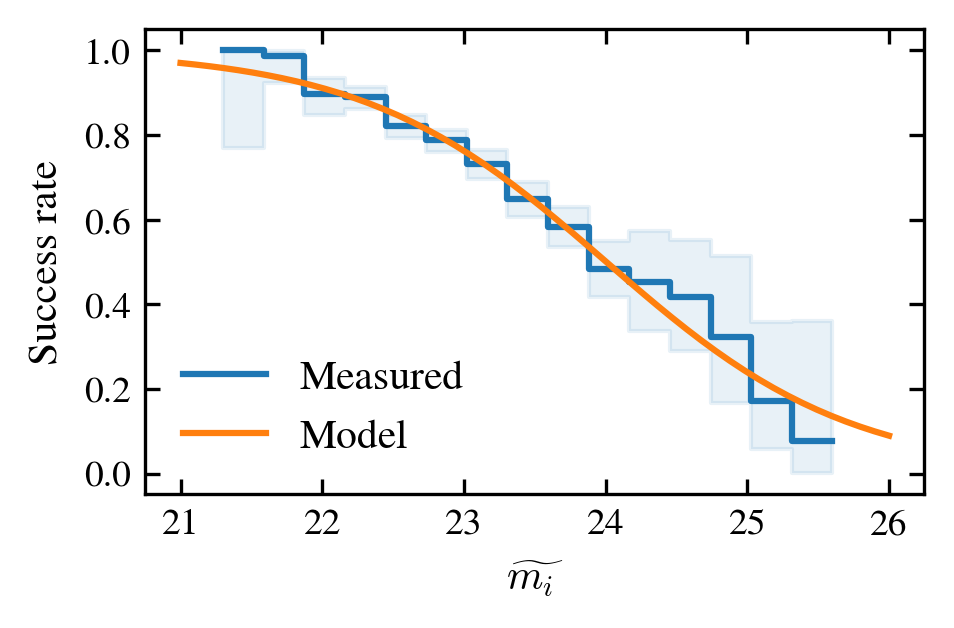

In [8]:
cat["mag-time"] = cat["mag_i"] - 1.25*np.log10(cat["EXPTIME"]/6000)


fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.6*COLUMN_WIDTH))
ax, success, n_success, n_failure, bin_edges = make_success_plot(cat, colname="mag-time",nbins=15, range=(21.3,25.6),label="Measured")




y_train = cat["success"].astype(int)
x_train = cat["mag-time"].value.reshape(-1,1)


poly = PolynomialFeatures(1)

glm_binom = sm.GLM(y_train, poly.fit_transform(x_train), family=sm.families.Binomial())
res = glm_binom.fit()
print(res.summary())

x_pred = np.linspace(21,26).reshape(-1,1)

y_pred = res.get_prediction(poly.fit_transform(x_pred))

n_boot = 1000
rng = np.random.default_rng(42)
results_boot = np.zeros((n_boot, len(x_pred)))

# for i in range(n_boot):
#     boot_idx = rng.choice(len(x_pred),size=len(x_pred), replace=True)
#     glm_binom_boot = sm.GLM(y_train[boot_idx], poly.fit_transform(x_train[boot_idx]), family=sm.families.Binomial())
#     res_boot = glm_binom_boot.fit()
#     y_pred_boot = res_boot.get_prediction(poly.fit_transform(x_pred))
#     results_boot[i] = y_pred_boot.predicted_mean
    



ax.plot(x_pred,y_pred.predicted_mean,label="Model")
# ax.fill_between(np.squeeze(x_pred), np.quantile(results_boot,0.95,axis=0), np.quantile(results_boot,0.05,axis=0), alpha=0.1, color="C1")
# ax.fill_between(np.squeeze(x_pred), y_pred.conf_int()[:,1], y_pred.conf_int()[:,0], alpha=0.1, color="C1")
ax.set_xlabel(r"$\widetilde{m_{i}}$")
ax.set_ylabel("Success rate")
ax.legend(frameon=False,loc = "lower left")
plt.savefig("./figs/success_rate_model.pdf",bbox_inches="tight",dpi=300)

In [9]:
model_logistic = LogisticRegression(penalty=None)
model_logistic.fit(x_train,y_train)


y_pred =  model_logistic.predict_proba(x_pred)[:,1]

print(f"Coef:{float(model_logistic.coef_):.2f}, Intercept:{float(model_logistic.intercept_):.2f}")

Coef:-1.16, Intercept:27.89


In [10]:
n_boot = 1000
rng = np.random.default_rng(42)
results_boot = np.zeros((n_boot, len(x_pred)))
coef = []
intercept = []

for i in range(n_boot):
    boot_idx = rng.choice(len(x_train),size=len(x_train), replace=True)
    model_logistic = LogisticRegression(penalty=None)
    model_logistic.fit(x_train[boot_idx],y_train[boot_idx])
    y_pred_boot = model_logistic.predict_proba(x_pred)
    results_boot[i] = y_pred_boot[:,1]
    coef.append(model_logistic.coef_)
    intercept.append(model_logistic.intercept_)
intercept = np.concatenate(intercept)
coef = np.concatenate(coef)

In [11]:
print(f"Coef CI:{float(model_logistic.coef_) - np.percentile(coef, 2.5):.2f}-{np.percentile(coef, 97.5)-float(model_logistic.coef_):.2f}, Intercept:{float(model_logistic.intercept_)-np.percentile(intercept, 2.5):.2f}-{np.percentile(intercept, 97.5)-float(model_logistic.intercept_):.2f}")

Coef CI:0.06-0.15, Intercept:3.57-1.42


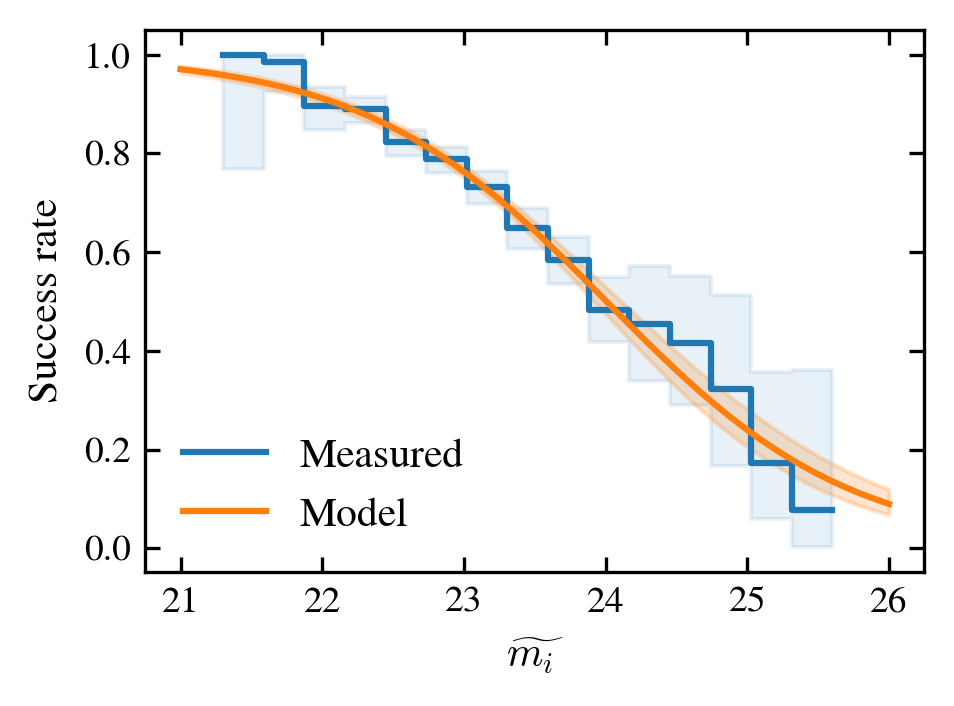

In [12]:

fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.7*COLUMN_WIDTH))
ax, success, n_success, n_failure, bin_edges = make_success_plot(cat, colname="mag-time",nbins=15, range=(21.3,25.6),label="Measured")

ax.plot(x_pred,y_pred,label="Model")
# ax.fill_between(np.squeeze(x_pred), np.quantile(results_boot,0.05,axis=0), np.quantile(results_boot,0.95,axis=0), alpha=0.1, color="C1")
# ax.fill_between(np.squeeze(x_pred), y_pred.conf_int()[:,1], y_pred.conf_int()[:,0], alpha=0.1, color="C1")
# ax.plot(x_pred,np.percentile(results_boot, 2.5, axis = 0))
# ax.plot(x_pred,np.percentile(results_boot, 97.5, axis = 0))
ax.fill_between(np.squeeze(x_pred), np.percentile(results_boot, 2.5, axis = 0),np.percentile(results_boot, 97.5, axis = 0), alpha=0.2, color="C1")
ax.set_xlabel(r"$\widetilde{m_{i}}$")
ax.set_ylabel("Success rate")
ax.legend(frameon=False,loc = "lower left")
plt.savefig("./figs/success_rate_model.pdf",bbox_inches="tight",dpi=300)

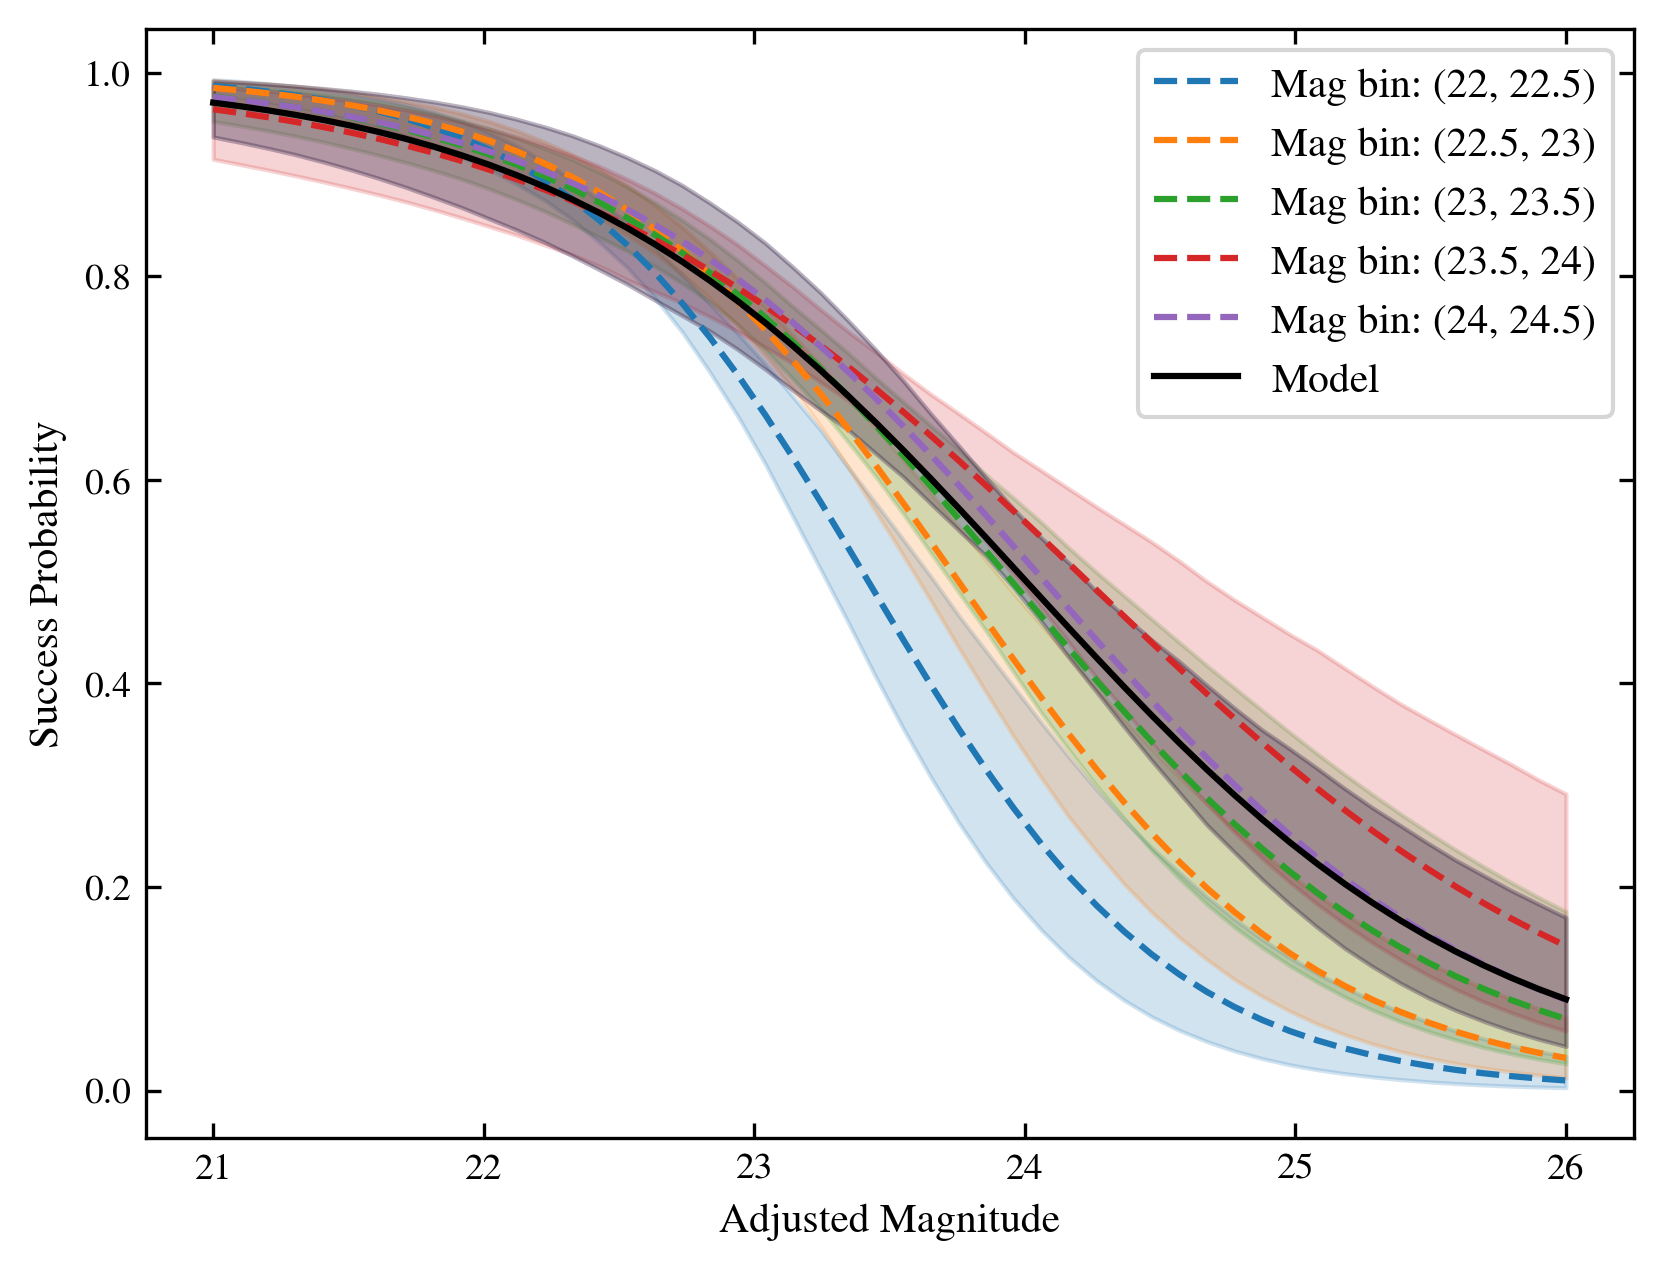

In [13]:
mag_bin_edges = [(22,22.5),(22.5,23),(23,23.5),(23.5,24),(24,24.5),(24.5,25)]


fig, ax = plt.subplots()
x_pred = np.linspace(21,26).reshape(-1,1)

for i, t in enumerate(mag_bin_edges[:-1]):
    cat_plot = cat[(cat["mag_i"]>=t[0]) & (cat["mag_i"]<t[1])]
    y_train_plot = cat_plot["success"].astype(int)
    x_train_plot = cat_plot["mag-time"].value.reshape(-1,1)
    model_logistic = LogisticRegression(penalty=None)
    model_logistic.fit(x_train_plot,y_train_plot)
    y_pred_plot =  model_logistic.predict_proba(x_pred)[:,1]
    ax.plot(x_pred,y_pred_plot,label = f"Mag bin: {t}", ls="--")
    n_boot = 1000
    rng = np.random.default_rng(42)
    results_boot = np.zeros((n_boot, len(x_pred)))
    coef = []
    intercept = []
    for j in range(n_boot):
        boot_idx = rng.choice(len(x_train_plot),size=len(x_train_plot), replace=True)
        model_logistic = LogisticRegression(penalty=None)
        model_logistic.fit(x_train_plot[boot_idx],y_train_plot[boot_idx])
        y_pred_boot = model_logistic.predict_proba(x_pred)
        results_boot[j] = y_pred_boot[:,1]
        coef.append(model_logistic.coef_)
        intercept.append(model_logistic.intercept_)
    intercept = np.concatenate(intercept)
    coef = np.concatenate(coef)
    ax.fill_between(np.squeeze(x_pred), np.percentile(results_boot, 2.5, axis = 0), np.percentile(results_boot, 97.5, axis = 0), alpha=0.2, color=f"C{i}")

ax.plot(x_pred,y_pred,label="Model",c="k")
ax.set_xlabel("Adjusted Magnitude")
ax.set_ylabel("Success Probability")
ax.fill_between(np.squeeze(x_pred), np.percentile(results_boot, 2.5, axis = 0),np.percentile(results_boot, 97.5, axis = 0), alpha=0.2, color="k")
plt.legend()

In [14]:

# fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.6*COLUMN_WIDTH))
# ax, success, n_success, n_failure, bin_edges = make_success_plot(cat, colname="mag-time",nbins=15, range=(21.3,25.6),label="Measured")

# ax.plot(x_pred,y_pred.predicted_mean,label="Model")
# ax.fill_between(np.squeeze(x_pred), np.percentile(results_boot, 2.5, axis = 0),np.percentile(results_boot, 97.5, axis = 0), alpha=0.5, color="C1")

# ax.plot(x_pred,sigmoid(-1.1970*x_pred + 28.7410),ls="--",c="k")
# # ax.plot(x_pred,sigmoid(-1.310*x_pred + 26.110),ls="--",c="k")
# # ax.plot(x_pred,sigmoid(-1.084*x_pred + 31.372),ls="--",c="k")
# ax.plot(x_pred,sigmoid(-1.084*x_pred + 26.110),ls="--",c="k")
# ax.plot(x_pred,sigmoid(-1.310*x_pred + 31.372),ls="--",c="k")
# ax.set_xlabel(r"$\widetilde{m_{i}}$")
# ax.set_ylabel("Success rate")
# ax.legend(frameon=False,loc = "lower left")
# # plt.savefig("./figs/success_rate_model.pdf",bbox_inches="tight",dpi=300)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 4723
Model:                            GLM   Df Residuals:                     4720
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2467.0
Date:                Thu, 05 Mar 2026   Deviance:                       4934.0
Time:                        07:48:55   Pearson chi2:                 4.67e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1004
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.7686      1.354     19.775      0.0

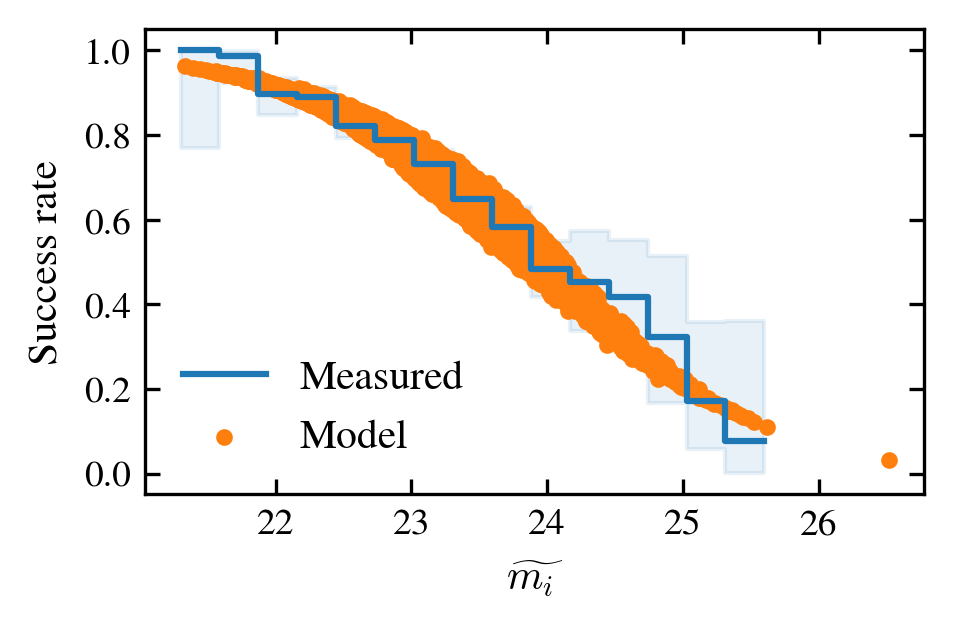

In [15]:
cat["mag-time"] = cat["mag_i"] - 1.25*np.log10(cat["EXPTIME"]/6000)


fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.6*COLUMN_WIDTH))
ax, success, n_success, n_failure, bin_edges = make_success_plot(cat, colname="mag-time",nbins=15, range=(21.3,25.6),label="Measured")

# y_train = np.array([np.delete(n_success,-2),np.delete(n_failure,-2)]).T
# # y_train = np.array([n_success,n_failure]).T
# x_train = (bin_edges[1:] + bin_edges[:-1])/2
# x_train = np.delete(x_train,-2)
# x_train = x_train.reshape(-1,1)


y_train = cat["success"].astype(int)
x_train = np.concatenate([cat["mag_i"][:,None],-1.25*np.log10(cat["EXPTIME"]/6000)[:,None]],axis=1)


poly = PolynomialFeatures(1)

glm_binom = sm.GLM(y_train, poly.fit_transform(x_train), family=sm.families.Binomial())
res = glm_binom.fit()
print(res.summary())

x_pred = x_train

y_pred = res.get_prediction(poly.fit_transform(x_pred))
ax.scatter(cat["mag-time"],y_pred.predicted_mean,label="Model",marker=".",c="C1")

ax.set_xlabel(r"$\widetilde{m_{i}}$")
ax.set_ylabel("Success rate")
ax.legend(frameon=False,loc = "lower left")
# plt.savefig("./figs/success_rate_model.pdf",bbox_inches="tight",dpi=300)

In [16]:
def sigmoid(y):
    return 1/(1+np.exp(-y))
    
def success_prob(magnitude, exptime, A=-1.2, B=28.74):
    mag_transformed = magnitude - 1.25*np.log10(exptime/100)
    success = sigmoid(A*mag_transformed + B)
   
    return success

In [17]:
def solve_quadratic(success, A, B, C):
    odds = logit(success)
    return (-B - np.sqrt(B**2 - 4*A*(C-odds)))/(2*A)

def solve_linear(success, A, B):
    odds = logit(success)
    return (odds - B)/A

def time_to_success(success, magnitude, A=-1.2, B=28.74, C=None):
    if C is not None:
        magnitude_transformed = solve_quadratic(success, A=A, B=B, C=C)
        # print(magnitde_transformed)
    else:
        magnitude_transformed = solve_linear(success, A=A, B=B)
    return 100*10**((magnitude - magnitude_transformed)/1.25) #minutes

def time_to_survey(success, magnitude, multiplexing, total_number, mirror_area, A=-1.2, B=28.74, C=None, hours_per_night=8, days_per_year=365,desi_mirror_area=8.658):
    # Fixed Mirror size: Account for that
    time_per_spectra = time_to_success(success, magnitude, A=A, B=B, C=C) * desi_mirror_area/mirror_area
    time_required_minutes = time_per_spectra*total_number/multiplexing
    return time_required_minutes/(60*hours_per_night*365) #yrs


def pred_success(magnitude,exptime, A=-1.2, B=28.74, hours_per_night=8):
    mag_transformed = magnitude - 1.25*np.log10(exptime*60/100)
    success = sigmoid(A*mag_transformed + B)
    # y_pred = res.get_prediction(poly.fit_transform(mag_transformed[:,None]))
    # success_int = (sigmoid(A_err[0]*mag_transformed + B_err[0]), sigmoid(A_err[1]*mag_transformed + B_err[1]))
    # return y_pred.predicted_mean, y_pred.conf_int()
    return success

# solve_quadratic(0.95, A=0.0477, B=-3.3865, C=53.8232)
# solve_linear(0.95, A=-1.1572, B=27.8182)
# print(""time_to_success(0.85, 22.5, A=-1.1572, B=27.8182))
print(f"Total time required: {time_to_survey(0.9, 25.3, 5000, 20000, mirror_area=8.658,hours_per_night=8*2/3):.2f} yrs (Linear Model)")
# print(f"Total time required: {time_to_survey(0.90, 24.1, 4000, 30000, A=0.0477, B=-3.3865, C=53.8232):.2f} nights (Quadratic Model)")

Total time required: 1.20 yrs (Linear Model)


In [18]:
print("Success rate for 25 hrs: ",pred_success(24.5,25,))
print("Success rate for 50 hrs: ",pred_success(24.5,50,))


print("Success rate for 25 hrs, LSST-Y1: ",pred_success(24.05,25,))
print("Success rate for 50 hrs, LSST-Y1: ",pred_success(24.05,50,))

Success rate for 25 hrs:  0.751034431148575
Success rate for 50 hrs:  0.8257328577168852
Success rate for 25 hrs, LSST-Y1:  0.8380970588189192
Success rate for 50 hrs, LSST-Y1:  0.8904827716280276


/tmp/ipykernel_1522754/1973295762.py:4: RuntimeWarning: divide by zero encountered in log
  return np.log(x/(1-x))


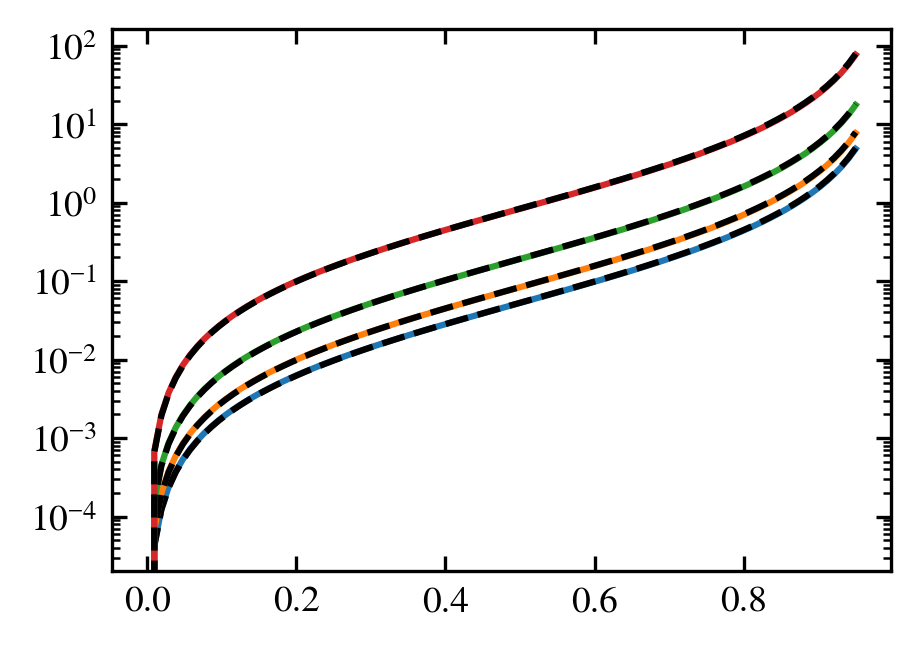

In [19]:
mag_grid = [23.8, 24.05, 24.5, 25.3]
label = ["DES-Y6", "LSST-Y1", "HSC-Y3", "LSST-Y10"]

def t_exp_desi(m_i,p_success):
    return 10**(-15.38 + 0.8*m_i +0.67*logit(p_success))
    
success_grid = np.linspace(0,0.95,100)
fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.7*COLUMN_WIDTH))
for i, m in enumerate(mag_grid):
    success = time_to_success(success_grid,m,)/(60*24)
    ax.plot(success_grid, success,label=f"{m} ({label[i]})")
    ax.plot(success_grid, t_exp_desi(m,success_grid)/(3600*24), ls="--",c="k")
    ax.set_yscale("log")








In [20]:
def hours2yrs(hours):
    
    return 2*(2/3)*hours/(8*365)
    # return hours*20000/(5000*4)
    # return hours * 2 / (1383/365) # two fields possible, 1383 total dark hours available per year
    


def yrs2hours(nights):
    return nights * (8*365) *3/2
    # return nights*(4500*6)/30000
    # return nights * (1383/365) /2

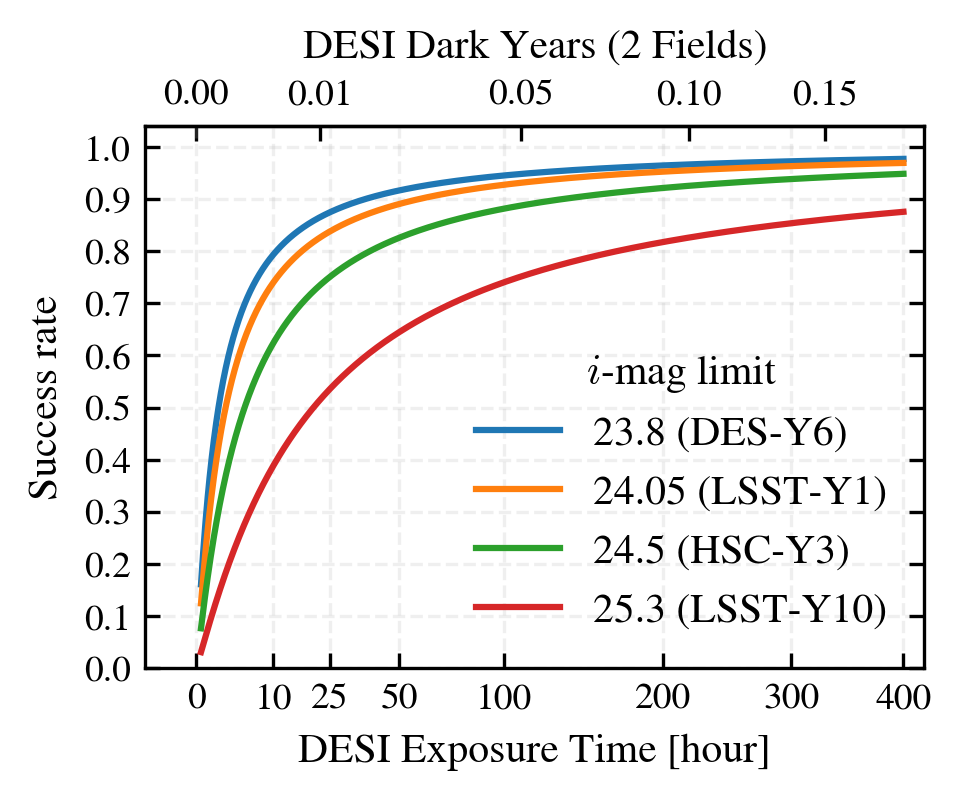

In [21]:
mag_grid = [23.8, 24.05, 24.5, 25.3]
label = ["DES-Y6", "LSST-Y1", "HSC-Y3", "LSST-Y10"]
# time_grid = np.logspace(1,3,1000)
time_grid = np.linspace(0.1,400,10000)
fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.7*COLUMN_WIDTH))


for i, m in enumerate(mag_grid):
    success = pred_success(m, time_grid)
    ax.plot(time_grid, success,label=f"{m} ({label[i]})")
    # ax.fill_between(time_grid, success_int[:,1], success_int[:,0], alpha=0.1)
# ax.set_xscale("log")


ax.legend(frameon=False,loc = "lower right", title="$i$-mag limit")
ax.set_ylabel("Success rate")
ax.set_xlabel("DESI Exposure Time [hour]")
ax.set_yticks(np.linspace(0,1,11))

ax.set_ylim(0,1.04)
ax.set_xlim(-5,420)
ax.grid(ls ="--", alpha=0.2, which="both")
ax.tick_params(top=False)
gamma = 0.6
ax.set_xscale("power_law",gamma=gamma)
secax = ax.secondary_xaxis('top', functions=(hours2yrs, yrs2hours))
secax.set_xlabel('DESI Dark Years (2 Fields)',labelpad=5)
secax.set_xscale("power_law", gamma=gamma)
ax.set_xticks([0, 10,25,50,100,200,300,400],)
# secax.set_xticks([0, 0.05, 0.1, 0.2, 0.3],)
secax.set_xticks([0, 0.01, 0.05, 0.1, 0.15],)

plt.savefig("./figs/success_rate_time.pdf",bbox_inches="tight",dpi=300)

In [22]:
with open('forecasts_FoM.yaml', 'r') as file:
    forecast_file = yaml.safe_load(file)
locals().update(forecast_file["LSST-Y1"])
locals().update(forecast_file["LSST-Y10"])

In [23]:
# plt.figure(figsize = (7,6))
# plt.plot(neff_list,np.array(w0_wa_fom_list)/w0_wa_fom_list[0], label = 'All bin equally' )
# plt.plot(neff_list_drop5,np.array(w0_wa_fom_list_drop5)/w0_wa_fom_list_drop5[0], label = 'Only fail in bin 5' )
# plt.plot(neff_list_drop45,np.array(w0_wa_fom_list_drop45)/w0_wa_fom_list_drop45[0], label = 'Only fail in bin 4 and 5' )
# plt.plot(neff_list_drop345,np.array(w0_wa_fom_list_drop345)/w0_wa_fom_list_drop345[0], label = 'Only fail in bin 3, 4 and 5' )


# sort_idx = np.argsort(neff_list)
# spl = piecewise_linear_interpolation(np.array(neff_list)[sort_idx], (np.array(w0_wa_fom_list)/w0_wa_fom_list[0])[sort_idx])
# x_plot = np.linspace(0.25,1.1,20)
# plt.plot(x_plot,spl(x_plot))
# plt.title('3x2pt, LSST Y10')

# plt.xlabel(r'$n_{eff}$ fraction')
# plt.ylabel(r'$FoM (n_{eff})/ FoM (n_{eff,0})$')
# plt.xlim(1.05, 0.05)
# plt.ylim(-0.05, 1.05)

Fom for 25 hrs, Y1 best case:  0.9647328990814923
Fom for 50 hrs, Y1 best case:  0.9761440087676373
Fom for 25 hrs, Y1 worst case:  0.6417213948672608
Fom for 50 hrs,  Y1 worst case:  0.7576468992294066


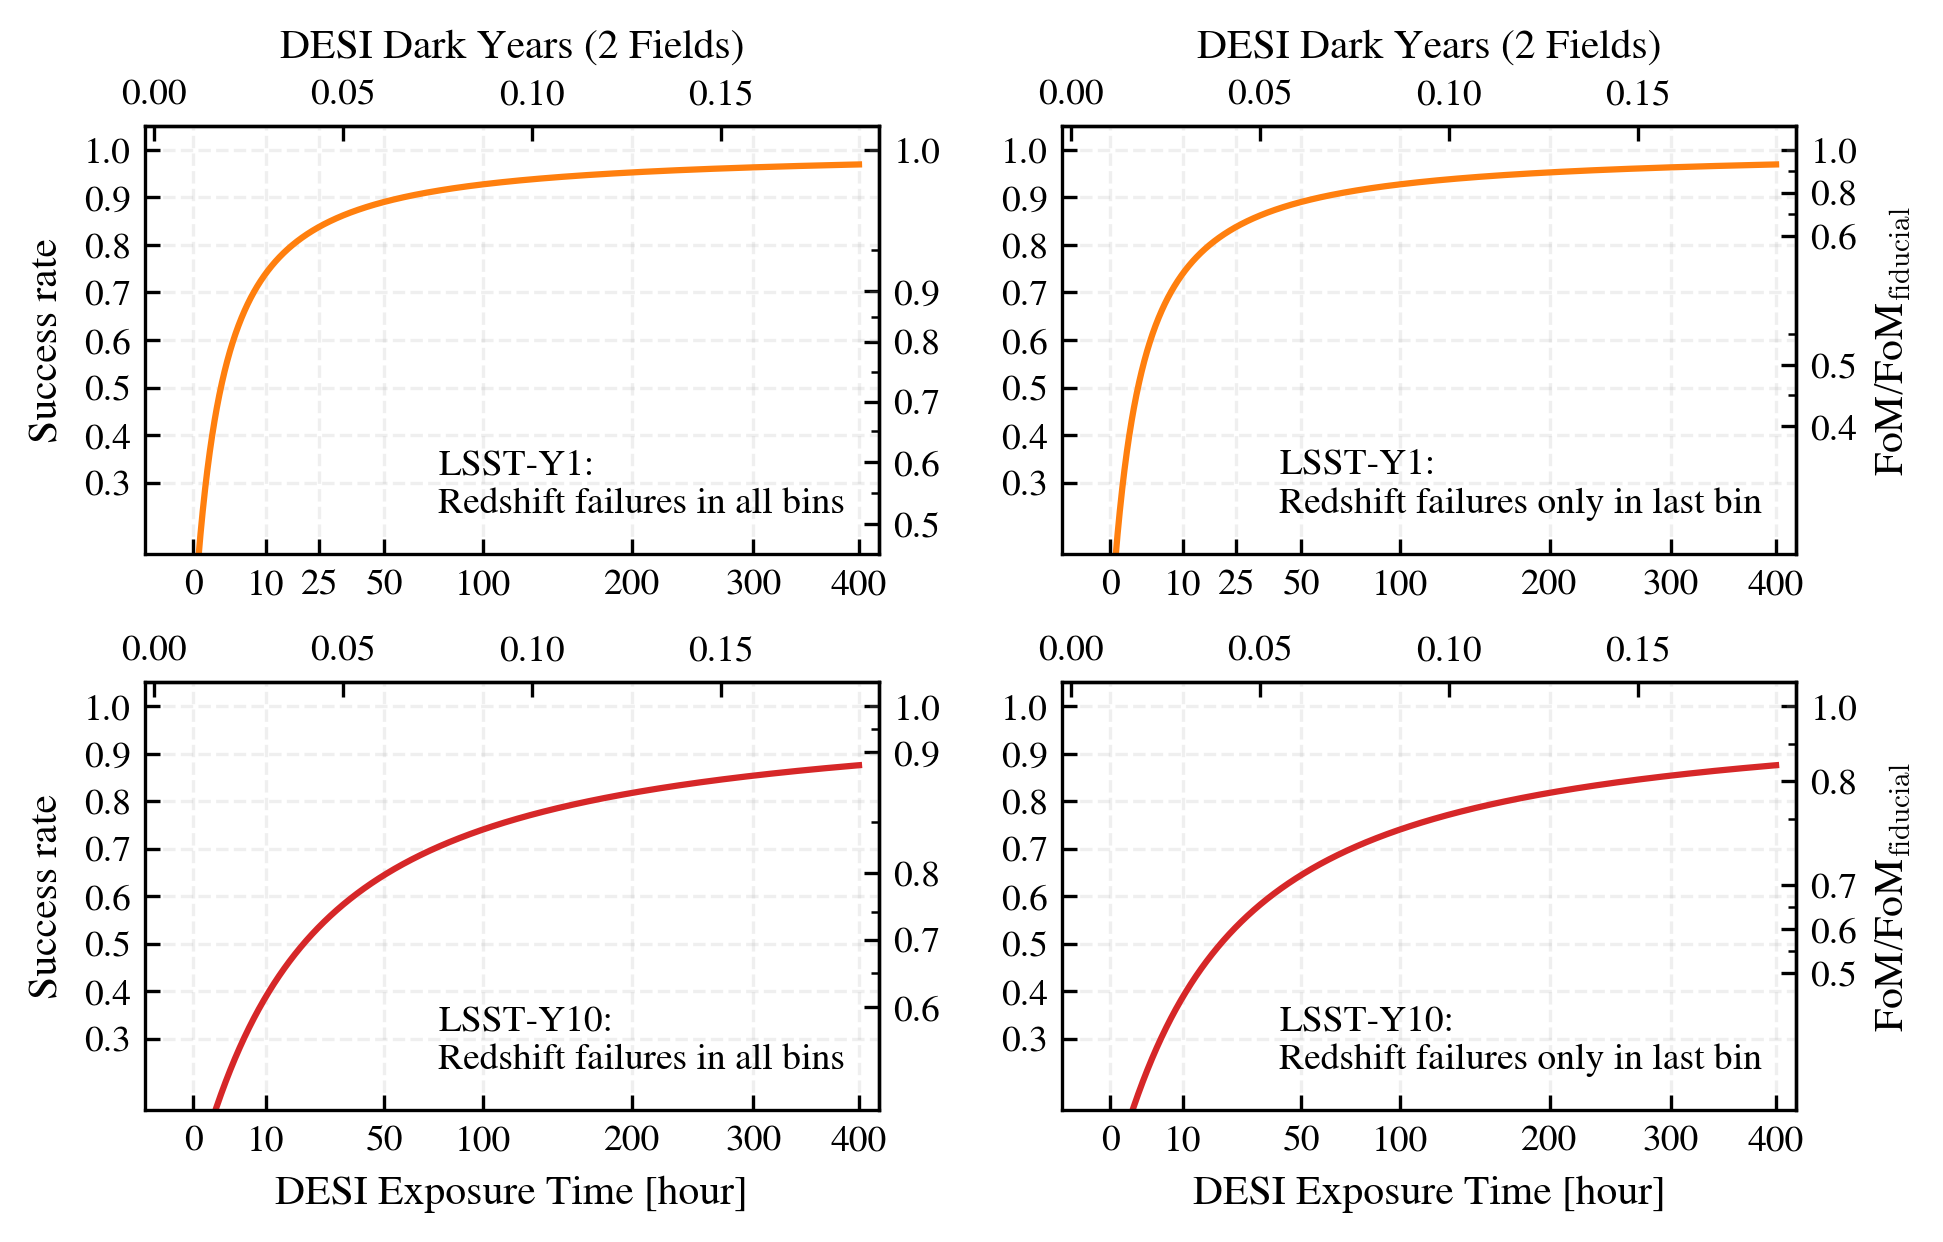

In [26]:
fig, ax = plt.subplots(2,2,figsize=(TEXT_WIDTH,0.6*TEXT_WIDTH))
ax = np.ravel(ax)
time_grid = np.linspace(0.1,400,10000)


sort_idx = np.argsort(neff_y1_list)
success_to_fom = piecewise_linear_interpolation(np.array(neff_y1_list)[sort_idx], (np.array(w0_wa_fom_y1_list)/w0_wa_fom_y1_list[0])[sort_idx])
fom_to_success = piecewise_linear_interpolation( (np.array(w0_wa_fom_y1_list)/w0_wa_fom_y1_list[0])[sort_idx], np.array(neff_y1_list)[sort_idx])
print("Fom for 25 hrs, Y1 best case: ",success_to_fom(0.8380970588189192))
print("Fom for 50 hrs, Y1 best case: ",success_to_fom(0.8904827716280276))

ax[0].plot(time_grid, pred_success(24.05, time_grid,),c="C1", label="LSST-Y1:\nRedshift failures in all bins")
secax_y = ax[0].secondary_yaxis("right",functions=(success_to_fom,fom_to_success))
secax_x = ax[0].secondary_xaxis('top', functions=(hours2yrs, yrs2hours))
ax[0].tick_params(top=False)
ax[0].tick_params(right=False)
ax[0].grid(ls ="--", alpha=0.2, which="both")

ax[0].set_ylim(0.15,1.05)
# secax_y.set_ylim(secax.get_ylim()[0],1.2)
ax[0].set_xlim(-5,420)

gamma = 0.6
ax[0].set_xscale("power_law",gamma=gamma)
secax_x.set_xscale("power_law", gamma=gamma)

ax[0].set_xticks([0, 10,25,50,100,200,300,400],)
secax_x.set_xticks([0, 10,50,100,200],)
ax[0].set_yticks([0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],)
secax_y.set_yticks([0.5,0.6,0.7,0.8,0.9,1],)
secax_y.set_yticks([0.55,0.65,0.75,0.85,0.95],minor=True)


secax_x.set_xlabel('DESI Dark Years (2 Fields)',labelpad=5)
ax[0].set_ylabel("Success rate")
ax[0].legend(frameon=False,handlelength=0,fontsize=SMALL_SIZE)


neff_worst = [1, np.min(neff_y1_list_drop5), np.min(neff_y1_list_drop45), np.min(neff_y1_list_drop345)]
fom_worst = [1,np.min(np.array(w0_wa_fom_y1_list_drop5)/w0_wa_fom_y1_list_drop5[0])+0.0005,
             np.min(np.array(w0_wa_fom_y1_list_drop45)/w0_wa_fom_y1_list_drop45[0]),
             np.min(np.array(w0_wa_fom_y1_list_drop345)/w0_wa_fom_y1_list_drop345[0]) ]
sort_idx = np.argsort(neff_worst)
success_to_fom = piecewise_linear_interpolation(np.array(neff_worst)[sort_idx], np.array(fom_worst)[sort_idx])
fom_to_success = piecewise_linear_interpolation( np.array(fom_worst)[sort_idx], np.array(neff_worst)[sort_idx])
print("Fom for 25 hrs, Y1 worst case: ",success_to_fom(0.8380970588189192))
print("Fom for 50 hrs,  Y1 worst case: ",success_to_fom(0.8904827716280276))
ax[1].plot(time_grid, pred_success(24.05, time_grid,),c="C1",label="LSST-Y1:\nRedshift failures only in last bin")
secax_y = ax[1].secondary_yaxis("right",functions=(success_to_fom,fom_to_success))
secax_x = ax[1].secondary_xaxis('top', functions=(hours2yrs, yrs2hours))
ax[1].tick_params(top=False)
ax[1].tick_params(right=False)
ax[1].grid(ls ="--", alpha=0.2, which="both")

ax[1].set_ylim(0.15,1.05)
ax[1].set_xlim(-5,420)

gamma = 0.6
ax[1].set_xscale("power_law",gamma=gamma)
secax_x.set_xscale("power_law", gamma=gamma)

ax[1].set_xticks([0, 10,25,50,100,200,300,400],)
secax_x.set_xticks([0, 10,50,100,200],)

ax[1].set_yticks([0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],)
secax_y.set_yticks([0.4,0.5,0.6,0.8,1],)
secax_y.set_yticks([0.45,0.55,0.7,0.9],minor=True)


secax_x.set_xlabel('DESI Dark Years (2 Fields)',labelpad=5)

secax_y.set_ylabel(r"FoM/FoM$_{\mathrm{fiducial}}$")

ax[1].legend(frameon=False,handlelength=0,fontsize=SMALL_SIZE)




sort_idx = np.argsort(neff_list)
success_to_fom = piecewise_linear_interpolation(np.array(neff_list)[sort_idx], (np.array(w0_wa_fom_list)/w0_wa_fom_list[0])[sort_idx])
fom_to_success = piecewise_linear_interpolation( (np.array(w0_wa_fom_list)/w0_wa_fom_list[0])[sort_idx], np.array(neff_list)[sort_idx])

 
ax[2].plot(time_grid, pred_success(25.3, time_grid,),c="C3", label="LSST-Y10:\nRedshift failures in all bins")
secax_y = ax[2].secondary_yaxis("right",functions=(success_to_fom,fom_to_success))
secax_x = ax[2].secondary_xaxis('top', functions=(hours2yrs, yrs2hours))
ax[2].tick_params(top=False)
ax[2].tick_params(right=False)
ax[2].grid(ls ="--", alpha=0.2, which="both")

ax[2].set_ylim(0.15,1.05)
# secax_y.set_ylim(secax.get_ylim()[0],1.2)
ax[2].set_xlim(-5,420)

gamma = 0.6
ax[2].set_xscale("power_law",gamma=gamma)
secax_x.set_xscale("power_law", gamma=gamma)

ax[2].set_xticks([0, 10,50,100,200,300,400],)
secax_x.set_xticks([0, 10,50,100,200],)
ax[2].set_yticks([0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],)
secax_y.set_yticks([0.6,0.7,0.8,0.9,1],)
secax_y.set_yticks([0.65,0.75,0.85,0.95],minor=True)


ax[2].set_xlabel("DESI Exposure Time [hour]")
ax[2].set_ylabel("Success rate")
ax[2].legend(frameon=False,handlelength=0,fontsize=SMALL_SIZE)


neff_worst = [1, np.min(neff_list_drop5), np.min(neff_list_drop45), np.min(neff_list_drop345)]
fom_worst = [1,np.min(np.array(w0_wa_fom_list_drop5)/w0_wa_fom_list_drop5[0]),
             np.min(np.array(w0_wa_fom_list_drop45)/w0_wa_fom_list_drop45[0]),
             np.min(np.array(w0_wa_fom_list_drop345)/w0_wa_fom_list_drop345[0]) ]
sort_idx = np.argsort(neff_worst)
success_to_fom = piecewise_linear_interpolation(np.array(neff_worst)[sort_idx], np.array(fom_worst)[sort_idx])
fom_to_success = piecewise_linear_interpolation( np.array(fom_worst)[sort_idx], np.array(neff_worst)[sort_idx])
ax[3].plot(time_grid, pred_success(25.3, time_grid,),c="C3",label="LSST-Y10:\nRedshift failures only in last bin")
secax_y = ax[3].secondary_yaxis("right",functions=(success_to_fom,fom_to_success))
secax_x = ax[3].secondary_xaxis('top', functions=(hours2yrs, yrs2hours))
ax[3].tick_params(top=False)
ax[3].tick_params(right=False)
ax[3].grid(ls ="--", alpha=0.2, which="both")

ax[3].set_ylim(0.15,1.05)
ax[3].set_xlim(-5,420)

gamma = 0.6
ax[3].set_xscale("power_law",gamma=gamma)
secax_x.set_xscale("power_law", gamma=gamma)

ax[3].set_xticks([0, 10,50,100,200,300,400],)
secax_x.set_xticks([0, 10,50,100,200],)

ax[3].set_yticks([0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],)
secax_y.set_yticks([0.5,0.6,0.7,0.8,1],)
secax_y.set_yticks([0.55,0.65,0.75,0.9],minor=True)


ax[3].set_xlabel("DESI Exposure Time [hour]")

secax_y.set_ylabel(r"FoM/FoM$_{\mathrm{fiducial}}$")

ax[3].legend(frameon=False,handlelength=0,fontsize=SMALL_SIZE)

plt.subplots_adjust(hspace=0.3,wspace=0.25)






plt.savefig("./figs/success_rate_time_cosmology.pdf",bbox_inches="tight",dpi=300)

In [52]:
# mag_grid = [23.8, 24.05, 24.5, 25.3]
# fig, ax = plt.subplots(1,1,figsize=(COLUMN_WIDTH,0.7*COLUMN_WIDTH))
# success_grid = np.linspace(0.001,0.999,100)
# for i, m in enumerate(mag_grid):
#     time = time_to_success(success_grid, m, A=-1.20, B=28.74,)
#     time2 = 10**(23+0.8*m+0.668*logit(success_grid))
#     ax.plot(success_grid,time)
#     ax.plot(success_grid,time,ls="--",c="k", lw=1)
#     ax.set_yscale("log")

In [22]:
# mag_grid = np.linspace(22,25.3,40)
# time_grid = np.logspace(1,4,40)

# for t,m in zip(time_grid, mag_grid):
    

In [23]:
# cat["mag-time"] = cat["mag_i"] - 1.25*np.log10(cat["EXPTIME"]/6000) 
# # ax, success, n_success, n_failure, bin_edges = make_success_plot(cat, colname="mag-time",nbins=15)

# y_train = np.array([np.delete(n_success,-2),np.delete(n_failure,-2)]).T
# x_train = (bin_edges[1:] + bin_edges[:-1])/2
# x_train = np.delete(x_train,-2)
# x_train = x_train.reshape(-1,1)
# x_order = []
# y_order = []
# for order in range(1,10):
    
#     poly = PolynomialFeatures(order)

#     glm_binom = sm.GLM(y_train, poly.fit_transform(x_train), family=sm.families.Binomial())
#     res = glm_binom.fit()
#     x_order.append(order)
#     y_order.append(res.llf)

# plt.scatter(x_order,y_order)
# plt.xlabel("Polynomial Order")
# plt.ylabel("Log likelihood")
# plt.grid(ls="--",alpha=0.5)